(6435, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB
None
             Store  Weekly_Sales  Holiday_Flag  Temperature   Fuel_Price  \
count  6435.000000  6.435000e+03   6435.000000  6435.000000  6435.000000   
mean     23.000000  1.046965e+06      0.069930    60.663782     3.358607   
std      12.988182  5.643666e+05      0.255049    18.444933     0.459020   
min       1.000000  2.099862e+05      0.000000    -2.060000     2.472000   
25%  

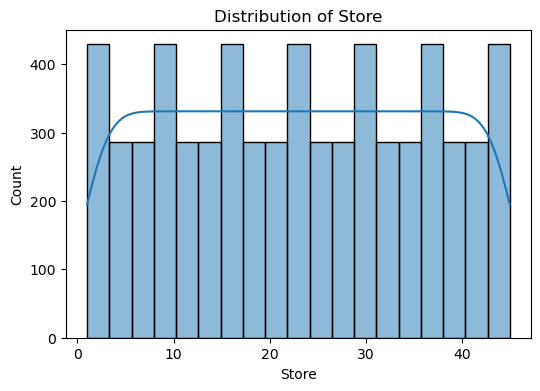

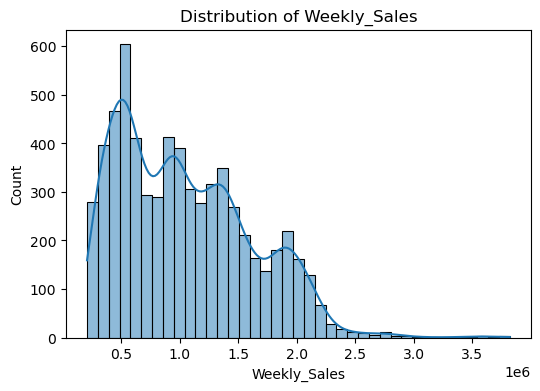

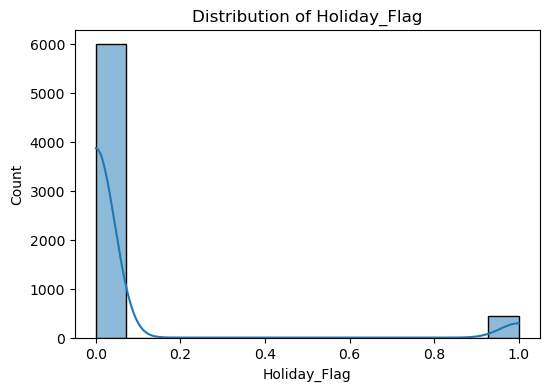

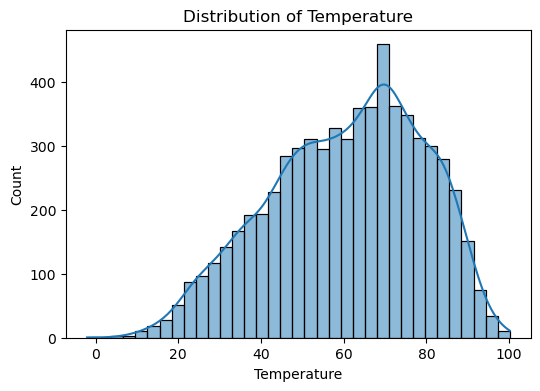

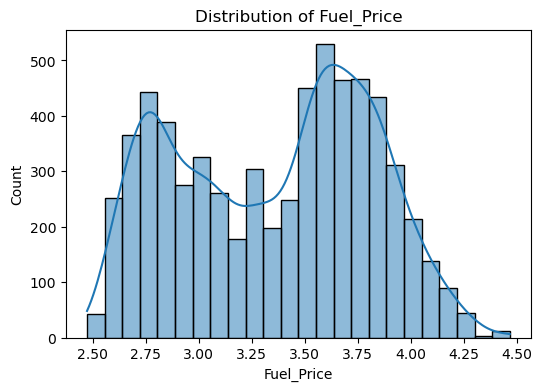

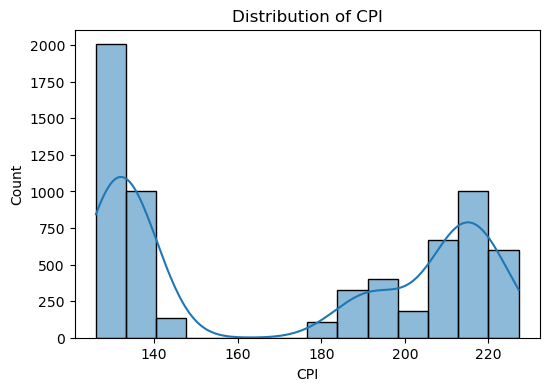

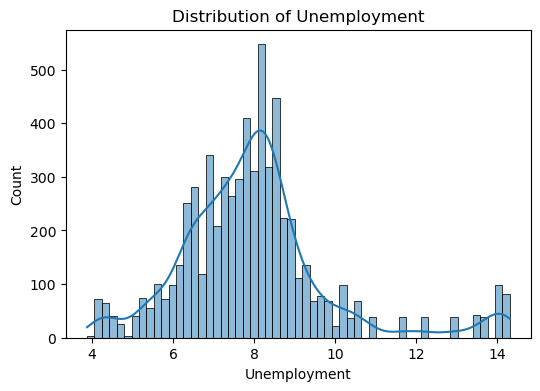

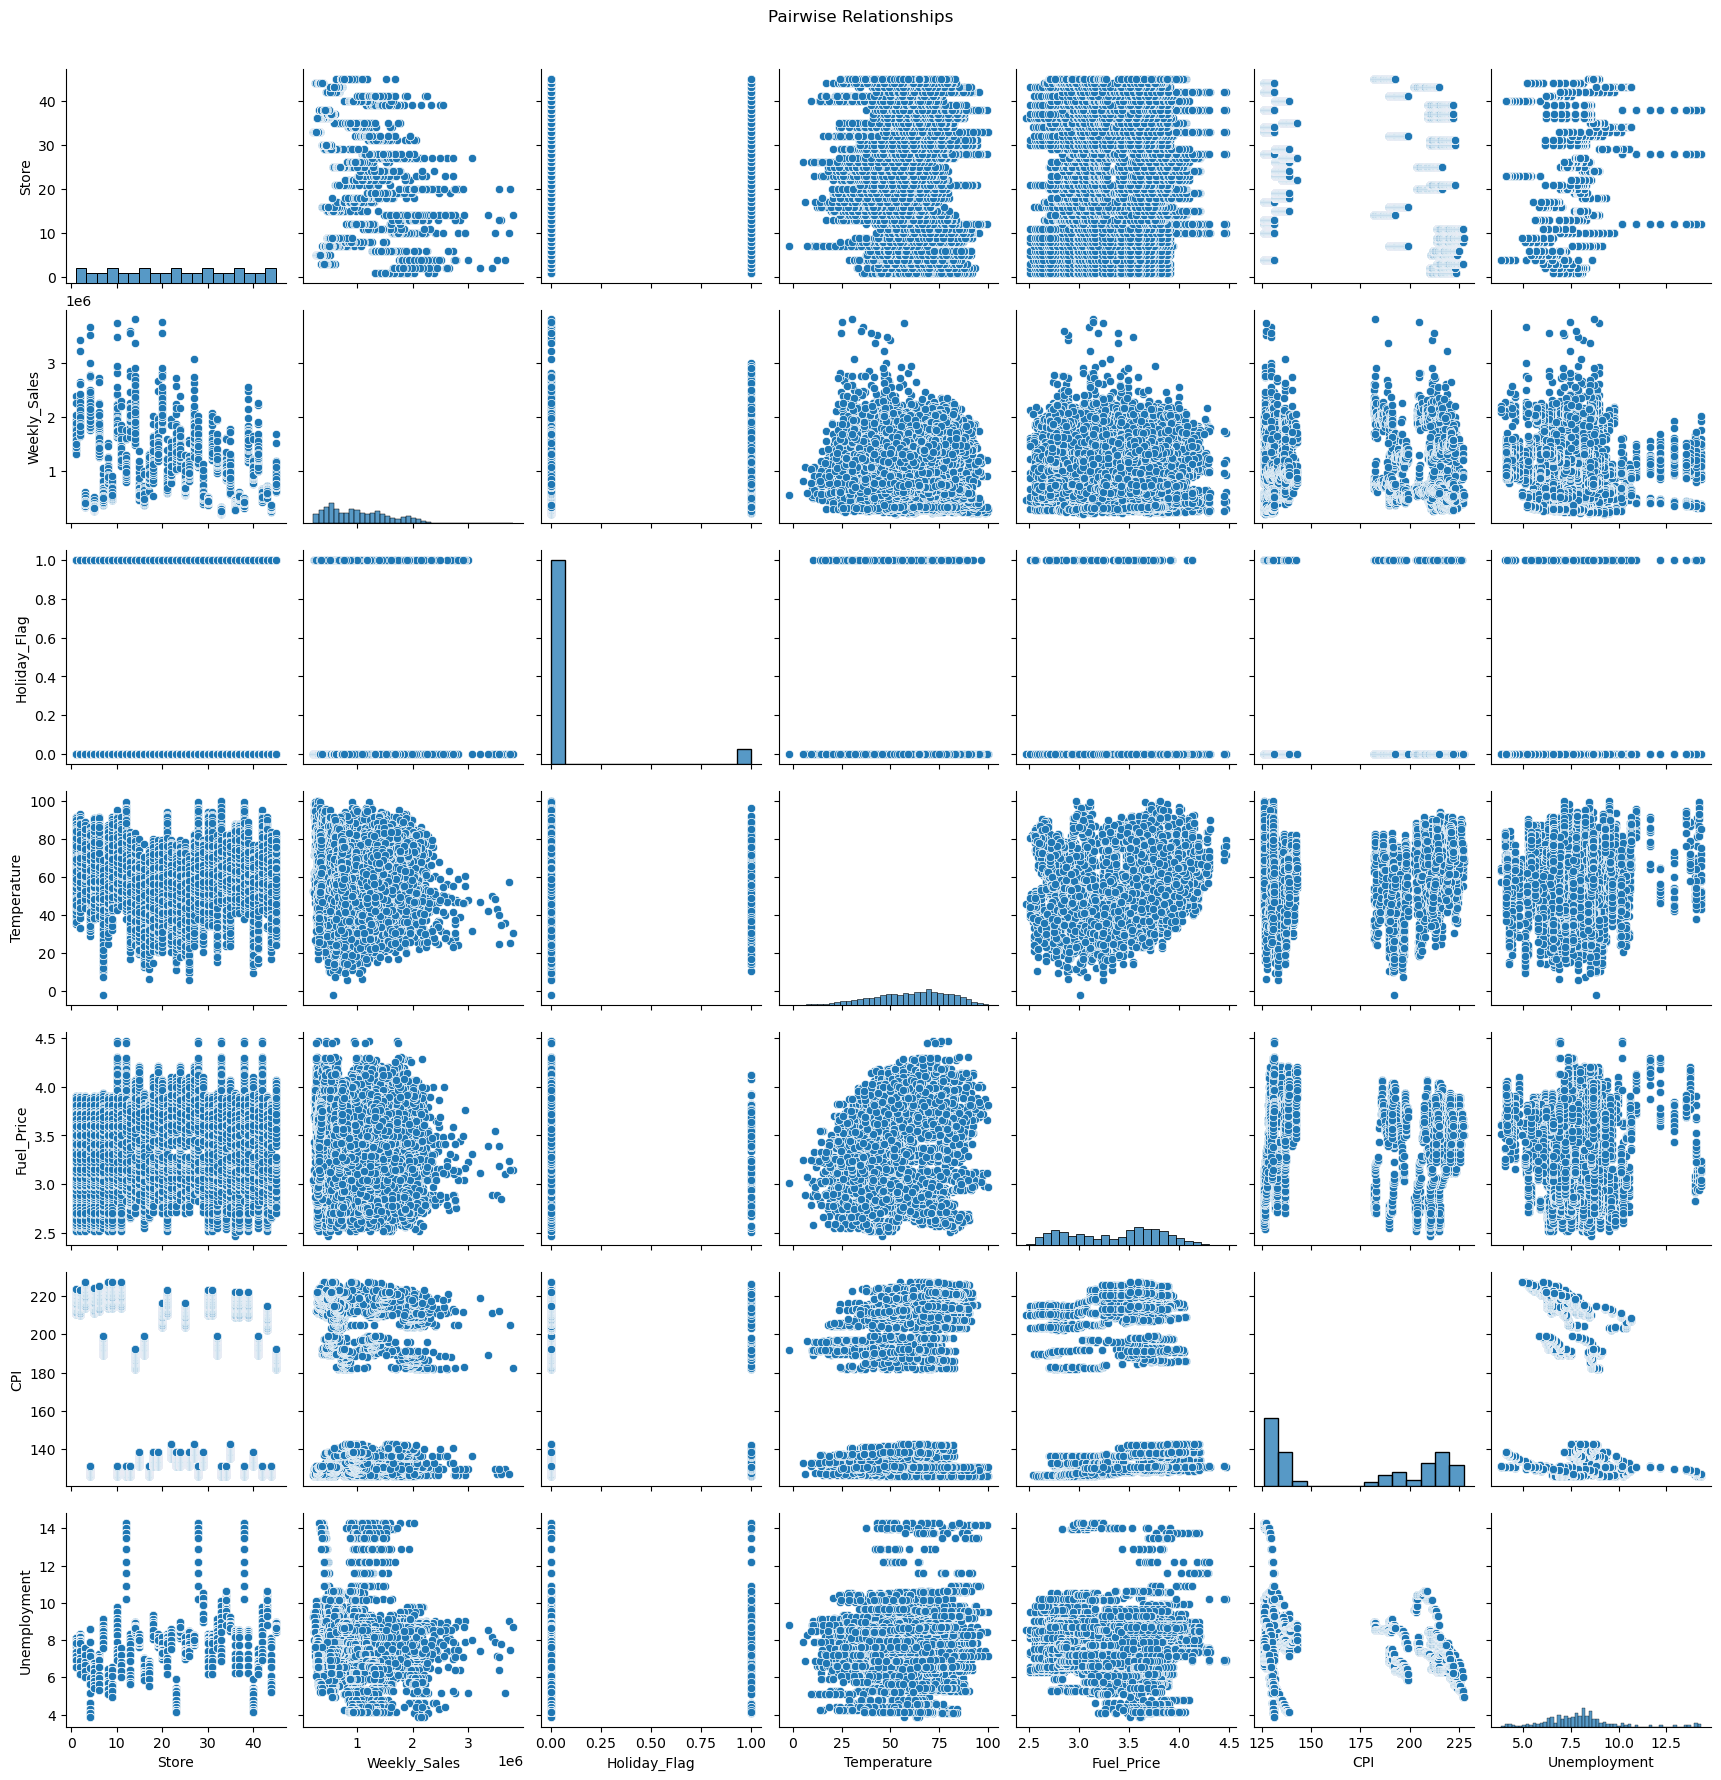

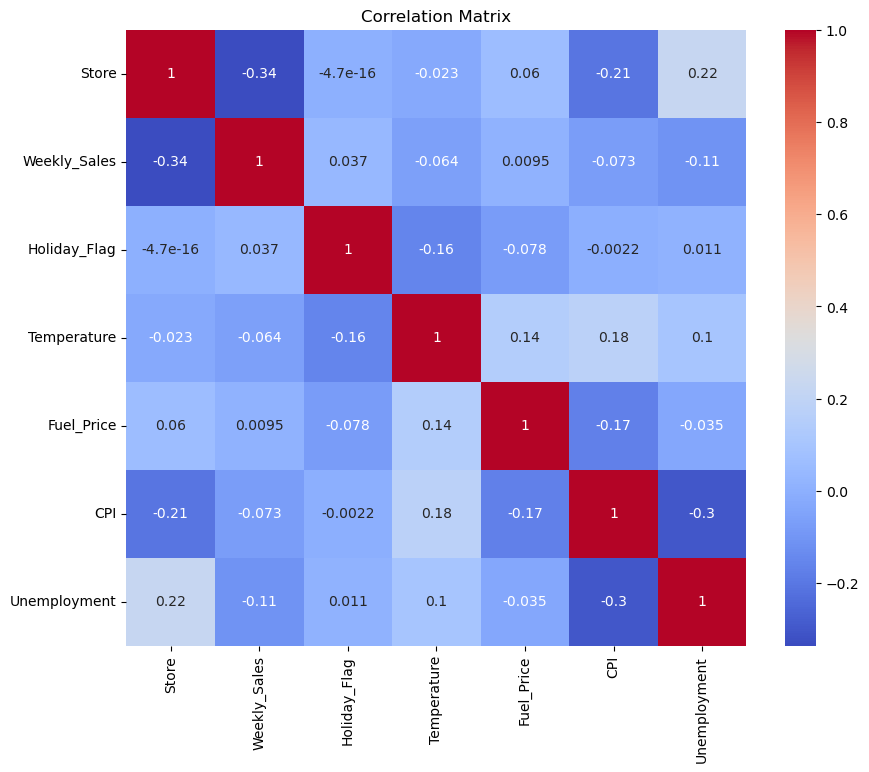

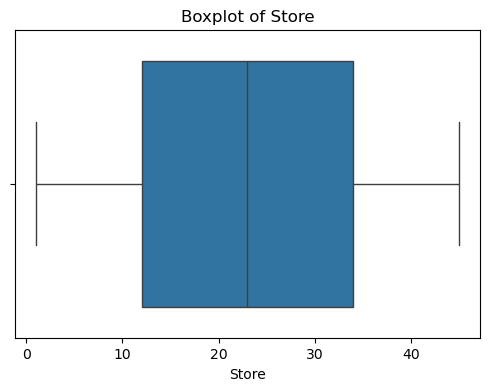

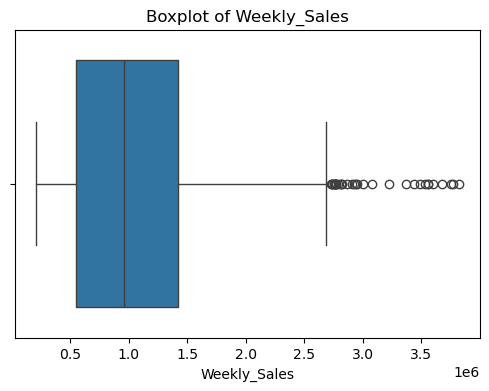

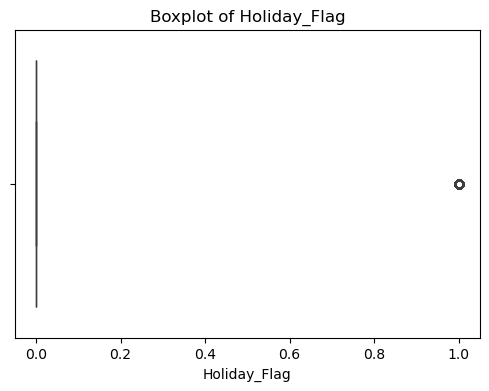

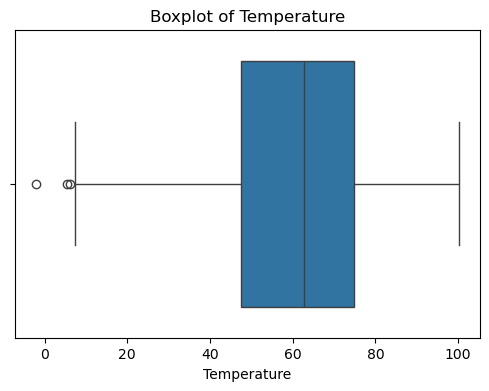

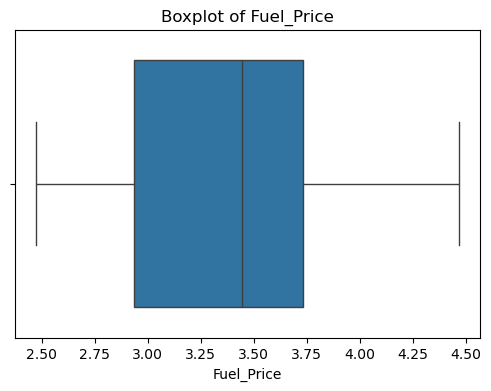

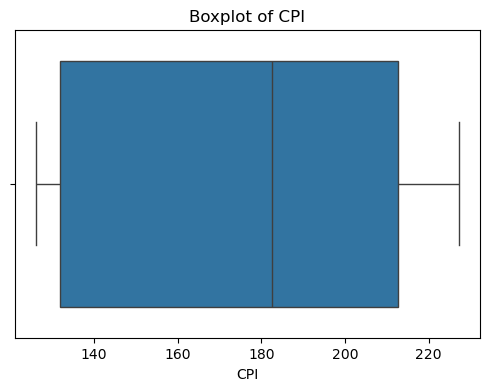

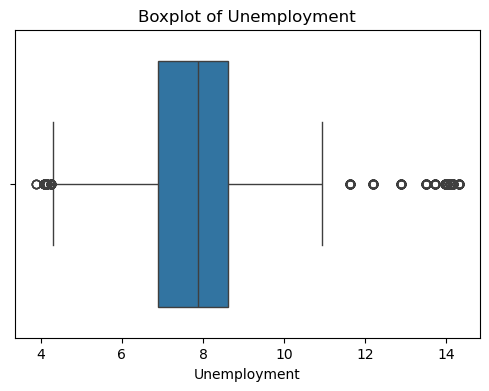

In [3]:
# Step 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Step 2: Load your dataset
df = pd.read_csv('walmart-sales-dataset-of-45stores.csv')  # Replace with your file path

# Step 3: Basic info
print(df.shape)
print(df.info())
print(df.describe())

# Step 4: Check for missing values
missing = df.isnull().sum()
print("Missing values:\n", missing)

# Step 5: Convert date columns to datetime format
# Identify date columns and convert them (assuming 'Date' is the column name)
date_columns = df.select_dtypes(include=['object']).columns
for col in date_columns:
    # Check if column contains date-like strings
    if df[col].str.contains('-').any():  # Simple check for date format
        try:
            df[col] = pd.to_datetime(df[col])
            print(f"Converted {col} to datetime")
        except:
            print(f"Could not convert {col} to datetime")

# Step 6: Univariate analysis - only on numeric columns
numeric_cols = df.select_dtypes(include=['number']).columns
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

# Step 7: Bivariate analysis - only on numeric columns
sns.pairplot(df[numeric_cols])
plt.suptitle('Pairwise Relationships', y=1.02)
plt.show()

# Step 8: Correlation heatmap - only on numeric columns
plt.figure(figsize=(10,8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

# Step 9: Outlier detection - only on numeric columns
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

In [7]:
import pandas as pd

df = pd.read_csv('walmart-sales-dataset-of-45stores.csv')  # Replace with your actual file
df.head()
df.info()

# Check for missing values
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


In [18]:
print(df.columns.tolist())

['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']


In [17]:
# Check for missing values
df.isnull().sum()

# Convert date column to datetime
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

# Drop irrelevant columns
df.drop(columns=['unnecessary_column'], inplace=True)

KeyError: "['unnecessary_column'] not found in axis"